### Figures for paper

In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt

%config InlineBackend.figure_format = 'retina'

In [2]:
# Load data
# Update path to use new data directory structure
data_dir = os.path.join(os.getcwd(), "Data")

# tight to naive (noiseless, QAOA P=3)
loaded_data_path = os.path.join(data_dir, "Noisy_Results_P4_random_init_20_graphs.npz")
loaded_data = np.load(loaded_data_path)


QUBO_EXP_VALS = loaded_data['QUBO_EXP_VALS']
QUBO_FEASIBILITY = loaded_data['QUBO_FEASIBILITY']
RQUBO_EXP_VALS = loaded_data['RQUBO_EXP_VALS']
RQUBO_FEASIBILITY = loaded_data['RQUBO_FEASIBILITY']

DICKE_QUBO_EXP_VALS = loaded_data['DICKE_QUBO_EXP_VALS'] if 'DICKE_QUBO_EXP_VALS' in loaded_data else None
DICKE_QUBO_FEASIBILITY = loaded_data['DICKE_QUBO_FEASIBILITY'] if 'DICKE_QUBO_FEASIBILITY' in loaded_data else None
PENALTY_MIXER_QUBO_EXP_VALS = loaded_data['PENALTY_MIXER_QUBO_EXP_VALS'] if 'PENALTY_MIXER_QUBO_EXP_VALS' in loaded_data else None
PENALTY_MIXER_QUBO_FEASIBILITY = loaded_data['PENALTY_MIXER_QUBO_FEASIBILITY'] if 'PENALTY_MIXER_QUBO_FEASIBILITY' in loaded_data else None
XY_MIXER_EXP_VALS = loaded_data['XY_MIXER_EXP_VALS'] if 'XY_MIXER_EXP_VALS' in loaded_data else None
XY_MIXER_FEASIBILITY = loaded_data['XY_MIXER_FEASIBILITY'] if 'XY_MIXER_FEASIBILITY' in loaded_data else None

number_of_pens = QUBO_EXP_VALS.shape[1]
penalty_list = np.linspace(0, 1, number_of_pens)
num_graphs = QUBO_EXP_VALS.shape[0]

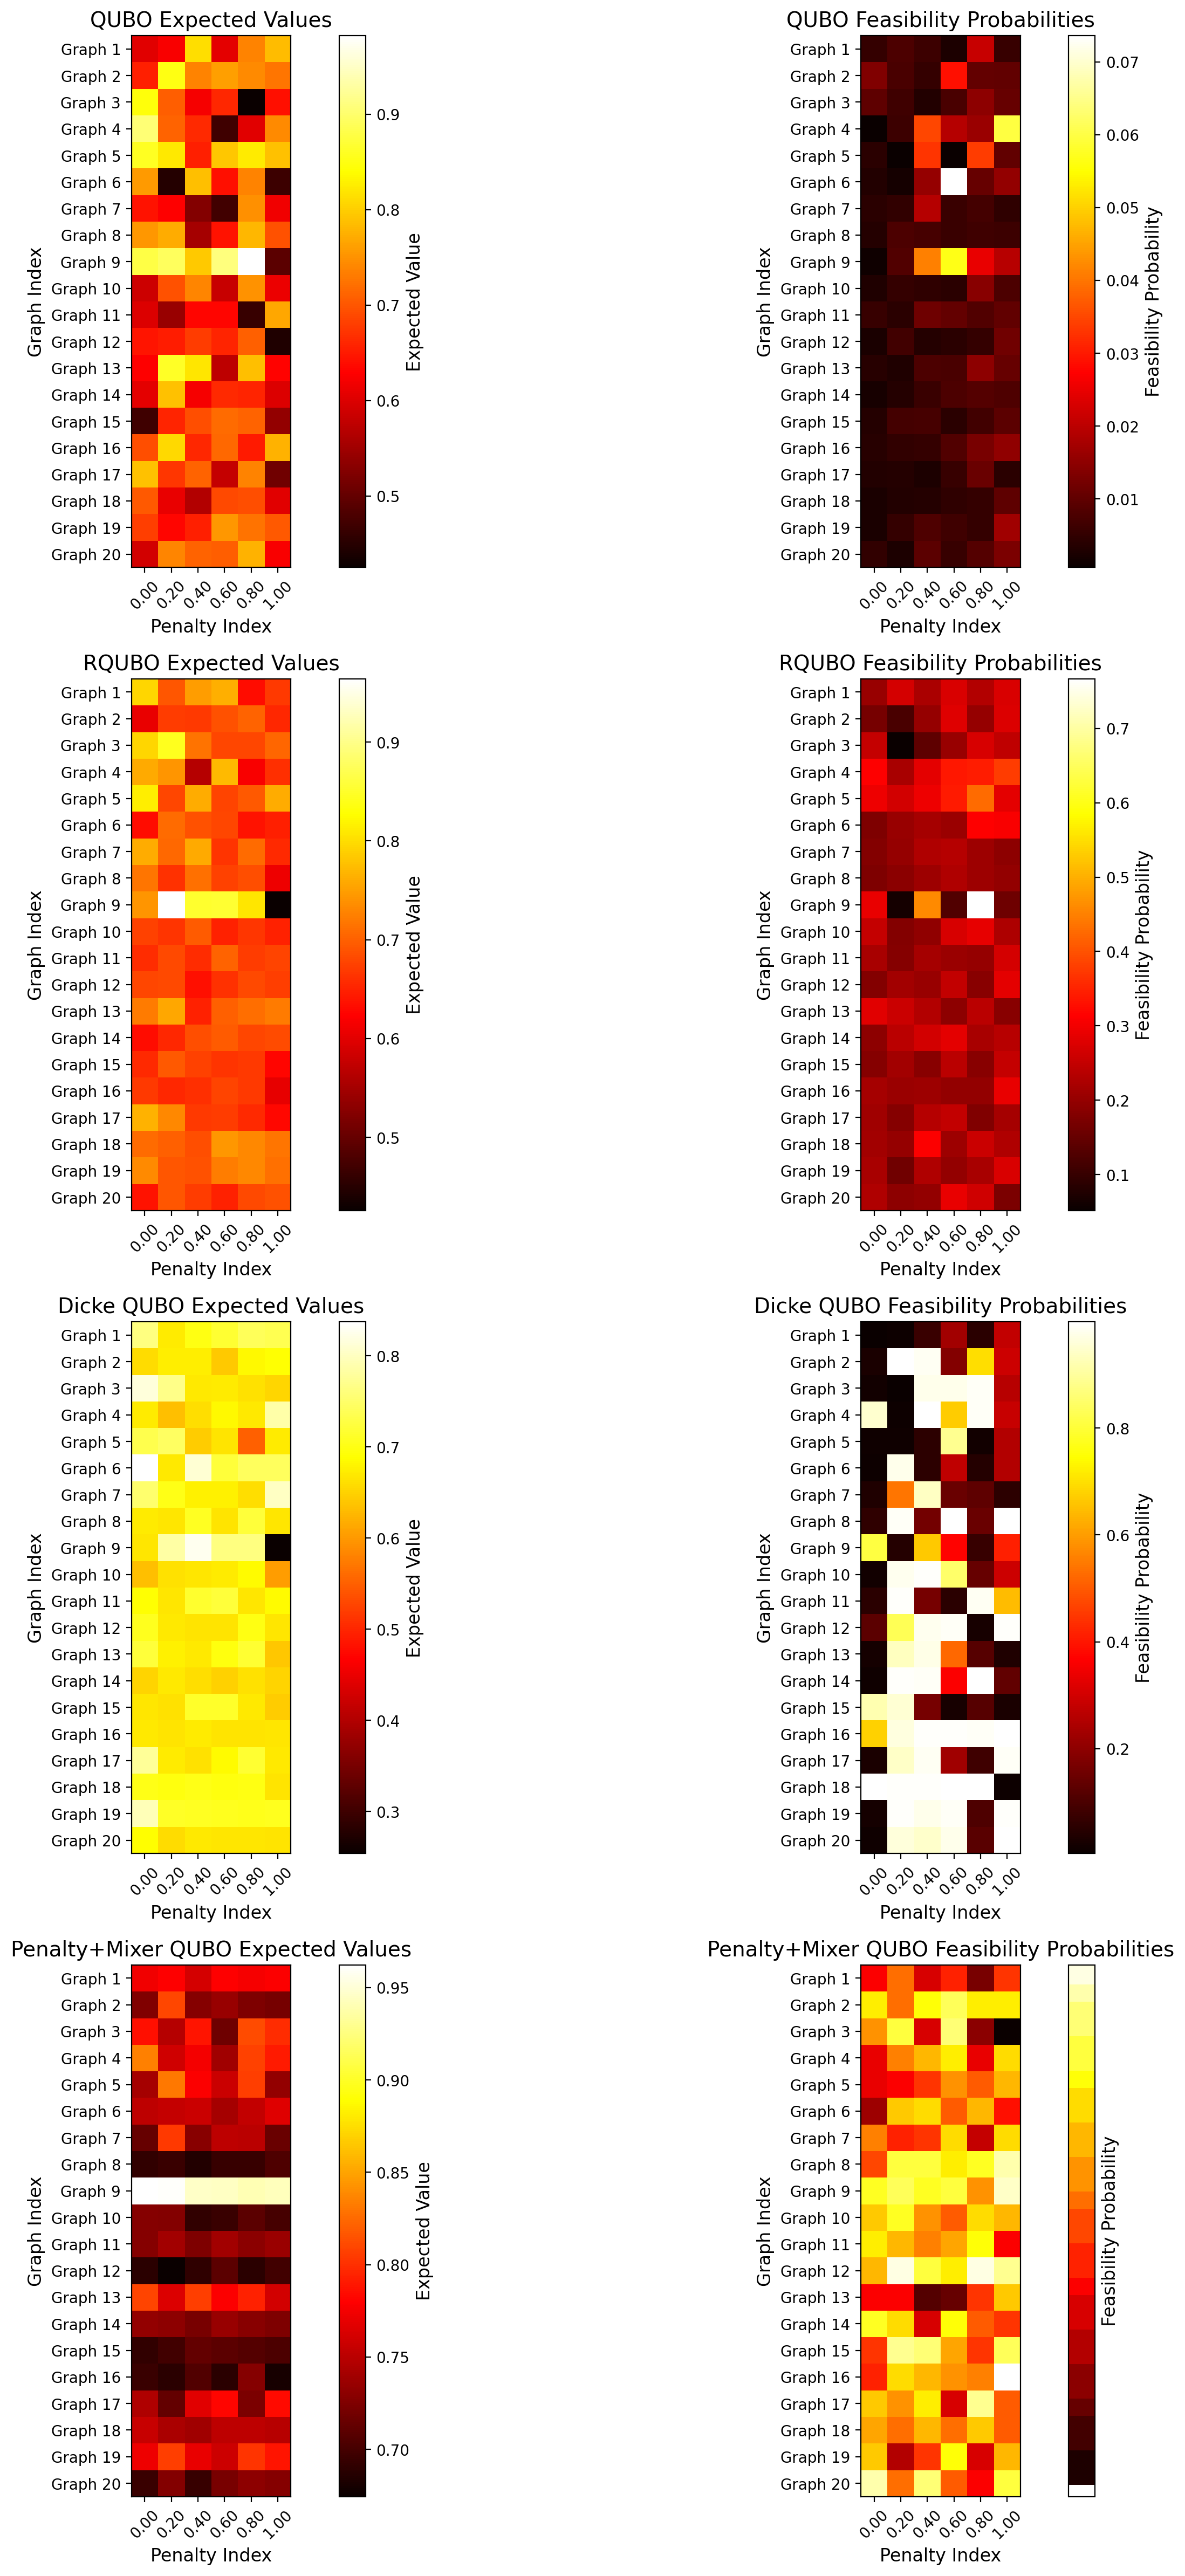

In [3]:
rows = [
    ("QUBO", QUBO_EXP_VALS, QUBO_FEASIBILITY),
    ("RQUBO", RQUBO_EXP_VALS, RQUBO_FEASIBILITY),
]
if DICKE_QUBO_EXP_VALS is not None:
    rows.append(("Dicke QUBO", DICKE_QUBO_EXP_VALS, DICKE_QUBO_FEASIBILITY))
if PENALTY_MIXER_QUBO_EXP_VALS is not None:
    rows.append(("Penalty+Mixer QUBO", PENALTY_MIXER_QUBO_EXP_VALS, PENALTY_MIXER_QUBO_FEASIBILITY))

fig, axs = plt.subplots(len(rows), 2, figsize=(16, 6 * len(rows)), squeeze=False)

for row_idx, (label, exp_vals, feas_vals) in enumerate(rows):
    im0 = axs[row_idx, 0].imshow(exp_vals, cmap='hot', interpolation='nearest')
    cbar0 = fig.colorbar(im0, ax=axs[row_idx, 0])
    cbar0.set_label('Expected Value', fontsize=12)
    axs[row_idx, 0].set_title(f'{label} Expected Values', fontsize=14)
    axs[row_idx, 0].set_xlabel('Penalty Index', fontsize=12)
    axs[row_idx, 0].set_ylabel('Graph Index', fontsize=12)
    axs[row_idx, 0].set_xticks(np.arange(len(penalty_list)))
    axs[row_idx, 0].set_xticklabels([f'{p:.2f}' for p in penalty_list], rotation=45, fontsize=10)
    axs[row_idx, 0].set_yticks(np.arange(num_graphs))
    axs[row_idx, 0].set_yticklabels([f'Graph {i+1}' for i in range(num_graphs)], fontsize=10)

    im1 = axs[row_idx, 1].imshow(feas_vals, cmap='hot', interpolation='nearest')
    cbar1 = fig.colorbar(im1, ax=axs[row_idx, 1])
    cbar1.set_label('Feasibility Probability', fontsize=12)
    axs[row_idx, 1].set_title(f'{label} Feasibility Probabilities', fontsize=14)
    axs[row_idx, 1].set_xlabel('Penalty Index', fontsize=12)
    axs[row_idx, 1].set_ylabel('Graph Index', fontsize=12)
    axs[row_idx, 1].set_xticks(np.arange(len(penalty_list)))
    axs[row_idx, 1].set_xticklabels([f'{p:.2f}' for p in penalty_list], rotation=45, fontsize=10)
    axs[row_idx, 1].set_yticks(np.arange(num_graphs))
    axs[row_idx, 1].set_yticklabels([f'Graph {i+1}' for i in range(num_graphs)], fontsize=10)

plt.tight_layout()
plt.show()

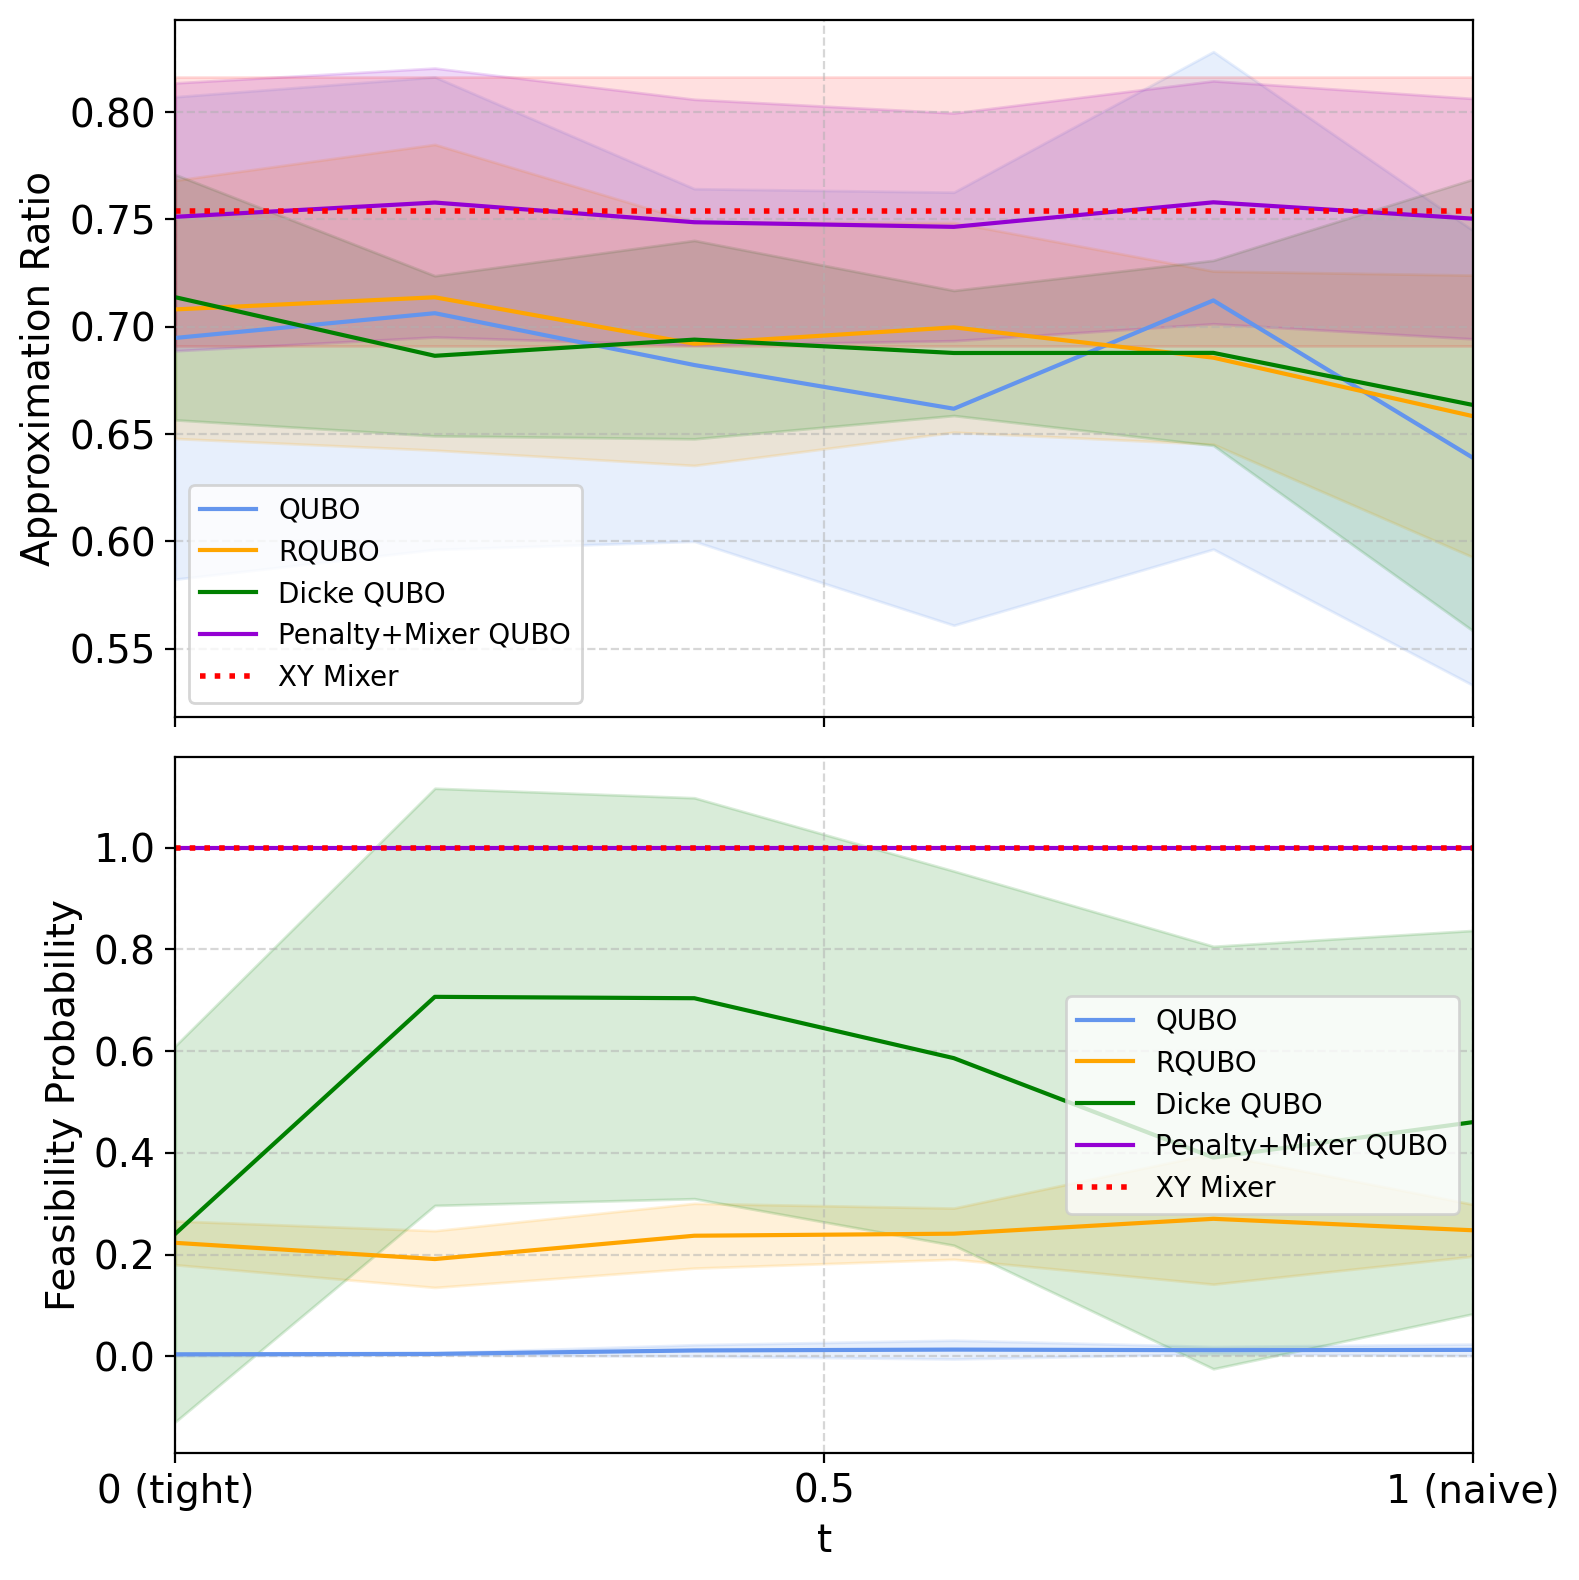

In [4]:
qubo_mean_over_graphs = np.mean(QUBO_EXP_VALS, axis=0)
qubo_std_over_graphs = np.std(QUBO_EXP_VALS, axis=0)
rqubo_mean_over_graphs = np.mean(RQUBO_EXP_VALS, axis=0)
rqubo_std_over_graphs = np.std(RQUBO_EXP_VALS, axis=0)

qubo_mean_feas_prob = np.mean(QUBO_FEASIBILITY, axis=0)
qubo_std_feas_prob = np.std(QUBO_FEASIBILITY, axis=0)
rqubo_mean_feas_prob = np.mean(RQUBO_FEASIBILITY, axis=0)
rqubo_std_feas_prob = np.std(RQUBO_FEASIBILITY, axis=0)

dicke_mean_over_graphs = None
penalty_mixer_mean_over_graphs = None
dicke_mean_feas_prob = None
penalty_mixer_mean_feas_prob = None

if DICKE_QUBO_EXP_VALS is not None:
    dicke_mean_over_graphs = np.mean(DICKE_QUBO_EXP_VALS, axis=0)
    dicke_std_over_graphs = np.std(DICKE_QUBO_EXP_VALS, axis=0)
    dicke_mean_feas_prob = np.mean(DICKE_QUBO_FEASIBILITY, axis=0)
    dicke_std_feas_prob = np.std(DICKE_QUBO_FEASIBILITY, axis=0)

if PENALTY_MIXER_QUBO_EXP_VALS is not None:
    penalty_mixer_mean_over_graphs = np.mean(PENALTY_MIXER_QUBO_EXP_VALS, axis=0)
    penalty_mixer_std_over_graphs = np.std(PENALTY_MIXER_QUBO_EXP_VALS, axis=0)
    penalty_mixer_mean_feas_prob = np.mean(PENALTY_MIXER_QUBO_FEASIBILITY, axis=0)
    penalty_mixer_std_feas_prob = np.std(PENALTY_MIXER_QUBO_FEASIBILITY, axis=0)

xy_mixer_mean = np.mean(XY_MIXER_EXP_VALS) if XY_MIXER_EXP_VALS is not None else None
xy_mixer_std = np.std(XY_MIXER_EXP_VALS) if XY_MIXER_EXP_VALS is not None and np.size(XY_MIXER_EXP_VALS) > 1 else None
xy_mixer_feas_mean = np.mean(XY_MIXER_FEASIBILITY) if XY_MIXER_FEASIBILITY is not None else None
xy_mixer_feas_std = np.std(XY_MIXER_FEASIBILITY) if XY_MIXER_FEASIBILITY is not None and np.size(XY_MIXER_FEASIBILITY) > 1 else None

# Plotting

# Custom colors:
qubo_color = "cornflowerblue"
rqubo_color = "orange"
dicke_qubo_color = "green"
penalty_mixer_color = "darkviolet"
xy_mixer_color = "red"

# Create a 2-row figure: top row for expected ratio, bottom row for feasibility probability.
# By specifying squeeze=False, axs is always a 2D array with shape (2, len(alpha_list))
fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

# -----------------------------
# Plot in the top row: Expected Approximation Ratio
# -----------------------------
ax_top = axs[0]
ax_top.plot(penalty_list, qubo_mean_over_graphs, label="QUBO", color=qubo_color, linestyle='-')
ax_top.fill_between(penalty_list,
                    np.array(qubo_mean_over_graphs) - np.array(qubo_std_over_graphs),
                    np.array(qubo_mean_over_graphs) + np.array(qubo_std_over_graphs),
                    color=qubo_color, alpha=0.15)

ax_top.plot(penalty_list, rqubo_mean_over_graphs, label="RQUBO", color=rqubo_color, linestyle='-')
ax_top.fill_between(penalty_list,
                    np.array(rqubo_mean_over_graphs) - np.array(rqubo_std_over_graphs),
                    np.array(rqubo_mean_over_graphs) + np.array(rqubo_std_over_graphs),
                    color=rqubo_color, alpha=0.15)

if dicke_mean_over_graphs is not None:
    ax_top.plot(penalty_list, dicke_mean_over_graphs, label="Dicke QUBO", color=dicke_qubo_color, linestyle='-')
    ax_top.fill_between(penalty_list,
                        np.array(dicke_mean_over_graphs) - np.array(dicke_std_over_graphs),
                        np.array(dicke_mean_over_graphs) + np.array(dicke_std_over_graphs),
                        color=dicke_qubo_color, alpha=0.15)

if penalty_mixer_mean_over_graphs is not None:
    ax_top.plot(penalty_list, penalty_mixer_mean_over_graphs, label="Penalty+Mixer QUBO", color=penalty_mixer_color, linestyle='-')
    ax_top.fill_between(penalty_list,
                        np.array(penalty_mixer_mean_over_graphs) - np.array(penalty_mixer_std_over_graphs),
                        np.array(penalty_mixer_mean_over_graphs) + np.array(penalty_mixer_std_over_graphs),
                        color=penalty_mixer_color, alpha=0.15)

if xy_mixer_mean is not None:
    ax_top.axhline(y=xy_mixer_mean, color=xy_mixer_color, linestyle=':', linewidth=2, label="XY Mixer")
    if xy_mixer_std is not None:
        ax_top.axhspan(xy_mixer_mean - xy_mixer_std, xy_mixer_mean + xy_mixer_std,
                       color=xy_mixer_color, alpha=0.12)

ax_top.grid(True, which='both', linestyle='--', alpha=0.5)
#ax_top.set_ylim(0, 1)
ax_top.set_ylabel('Approximation Ratio', fontsize=14)
ax_top.legend()
plt.grid

# -----------------------------
# Plot in the bottom row: Feasibility Probability
# -----------------------------
ax_bottom = axs[1]
ax_bottom.plot(penalty_list, qubo_mean_feas_prob, label="QUBO", color=qubo_color, linestyle='-')
ax_bottom.fill_between(penalty_list,
                    np.array(qubo_mean_feas_prob) - np.array(qubo_std_feas_prob),
                    np.array(qubo_mean_feas_prob) + np.array(qubo_std_feas_prob),
                    color=qubo_color, alpha=0.15)

ax_bottom.plot(penalty_list, rqubo_mean_feas_prob, label="RQUBO", color=rqubo_color, linestyle='-')
ax_bottom.fill_between(penalty_list,
                    np.array(rqubo_mean_feas_prob) - np.array(rqubo_std_feas_prob),
                    np.array(rqubo_mean_feas_prob) + np.array(rqubo_std_feas_prob),
                    color=rqubo_color, alpha=0.15)

if dicke_mean_feas_prob is not None:
    ax_bottom.plot(penalty_list, dicke_mean_feas_prob, label="Dicke QUBO", color=dicke_qubo_color, linestyle='-')
    ax_bottom.fill_between(penalty_list,
                        np.array(dicke_mean_feas_prob) - np.array(dicke_std_feas_prob),
                        np.array(dicke_mean_feas_prob) + np.array(dicke_std_feas_prob),
                        color=dicke_qubo_color, alpha=0.15)

if penalty_mixer_mean_feas_prob is not None:
    ax_bottom.plot(penalty_list, penalty_mixer_mean_feas_prob, label="Penalty+Mixer QUBO", color=penalty_mixer_color, linestyle='-')
    ax_bottom.fill_between(penalty_list,
                        np.array(penalty_mixer_mean_feas_prob) - np.array(penalty_mixer_std_feas_prob),
                        np.array(penalty_mixer_mean_feas_prob) + np.array(penalty_mixer_std_feas_prob),
                        color=penalty_mixer_color, alpha=0.15)

if xy_mixer_feas_mean is not None:
    ax_bottom.axhline(y=xy_mixer_feas_mean, color=xy_mixer_color, linestyle=':', linewidth=2, label="XY Mixer")
    if xy_mixer_feas_std is not None:
        ax_bottom.axhspan(xy_mixer_feas_mean - xy_mixer_feas_std, xy_mixer_feas_mean + xy_mixer_feas_std,
                          color=xy_mixer_color, alpha=0.12)

ax_bottom.grid(True, which='both', linestyle='--', alpha=0.5)
#ax_bottom.set_ylim(0, .5)
ax_bottom.set_xlabel('t', fontsize=14)
ax_bottom.set_xticks([0, 0.5, 1])
ax_bottom.set_xticklabels(["0 (tight)", "0.5", "1 (naive)"], fontsize=12)
ax_bottom.set_ylabel('Feasibility Probability', fontsize=14)
ax_bottom.legend()

for ax in axs:
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    plt.xlim(0, 1)

plt.tight_layout()

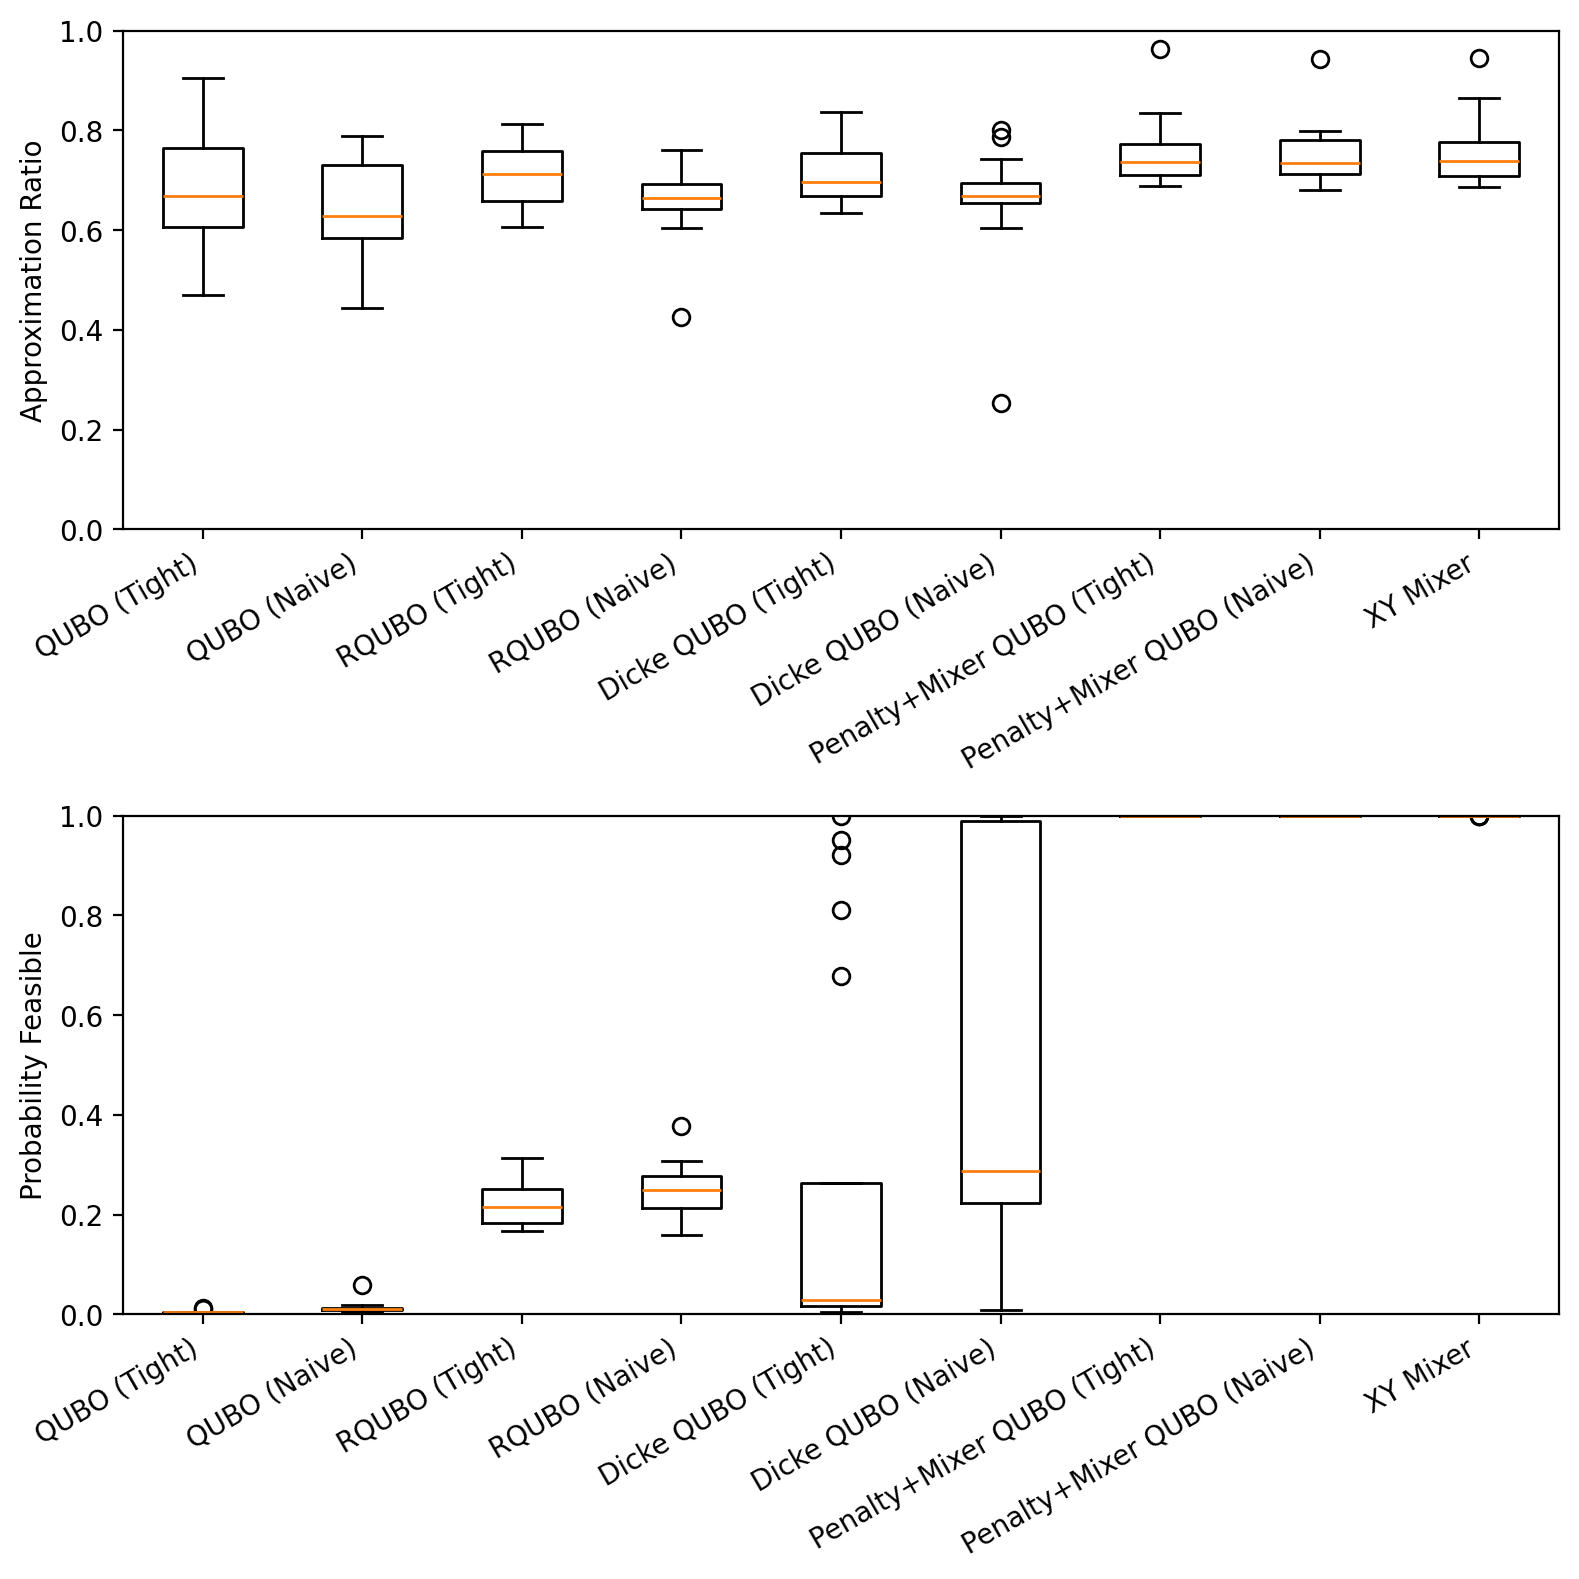

In [5]:
# Box Plot

model_specs = [
    ("QUBO (Tight)", QUBO_EXP_VALS[:, 0], QUBO_FEASIBILITY[:, 0]),
    ("QUBO (Naive)", QUBO_EXP_VALS[:, -1], QUBO_FEASIBILITY[:, -1]),
    ("RQUBO (Tight)", RQUBO_EXP_VALS[:, 0], RQUBO_FEASIBILITY[:, 0]),
    ("RQUBO (Naive)", RQUBO_EXP_VALS[:, -1], RQUBO_FEASIBILITY[:, -1]),
]

if DICKE_QUBO_EXP_VALS is not None:
    model_specs.append(("Dicke QUBO (Tight)", DICKE_QUBO_EXP_VALS[:, 0], DICKE_QUBO_FEASIBILITY[:, 0]))
    model_specs.append(("Dicke QUBO (Naive)", DICKE_QUBO_EXP_VALS[:, -1], DICKE_QUBO_FEASIBILITY[:, -1]))

if PENALTY_MIXER_QUBO_EXP_VALS is not None:
    model_specs.append(("Penalty+Mixer QUBO (Tight)", PENALTY_MIXER_QUBO_EXP_VALS[:, 0], PENALTY_MIXER_QUBO_FEASIBILITY[:, 0]))
    model_specs.append(("Penalty+Mixer QUBO (Naive)", PENALTY_MIXER_QUBO_EXP_VALS[:, -1], PENALTY_MIXER_QUBO_FEASIBILITY[:, -1]))

if XY_MIXER_EXP_VALS is not None:
    model_specs.append(("XY Mixer", XY_MIXER_EXP_VALS, XY_MIXER_FEASIBILITY))

model_labels = [label for label, _, _ in model_specs]
model_means = {label: values for label, values, _ in model_specs}
model_feasibility_probs = {label: feas for label, _, feas in model_specs}

fig, axs = plt.subplots(2, 1, figsize=(8, 8))

# First subplot: Approximation Ratio
data_for_boxplot = [model_means[label] for label in model_labels]
axs[0].boxplot(data_for_boxplot, tick_labels=model_labels)
axs[0].set_ylabel("Approximation Ratio")
axs[0].set_xticklabels(model_labels, rotation=30, ha='right')
axs[0].set_ylim(0, 1)

# Second subplot: Probability Feasible
data_for_boxplot = [model_feasibility_probs[label] for label in model_labels]
axs[1].boxplot(data_for_boxplot, tick_labels=model_labels)
axs[1].set_ylabel("Probability Feasible")
axs[1].set_xticklabels(model_labels, rotation=30, ha='right')
axs[1].set_ylim(0, 1)

plt.tight_layout()

## Filter out expected values of zero resulting from all shots being discarded due to infeasibility. This occurs especially with QUBO model which consistently has a low feasibility probability.

In [6]:
# For each column in data matrix, drop zero values and average the rest
def average_non_zero(data):
    return np.array([np.mean(col[col != 0]) for col in data.T])

def std_non_zero(data):
    return np.array([np.std(col[col != 0]) for col in data.T])

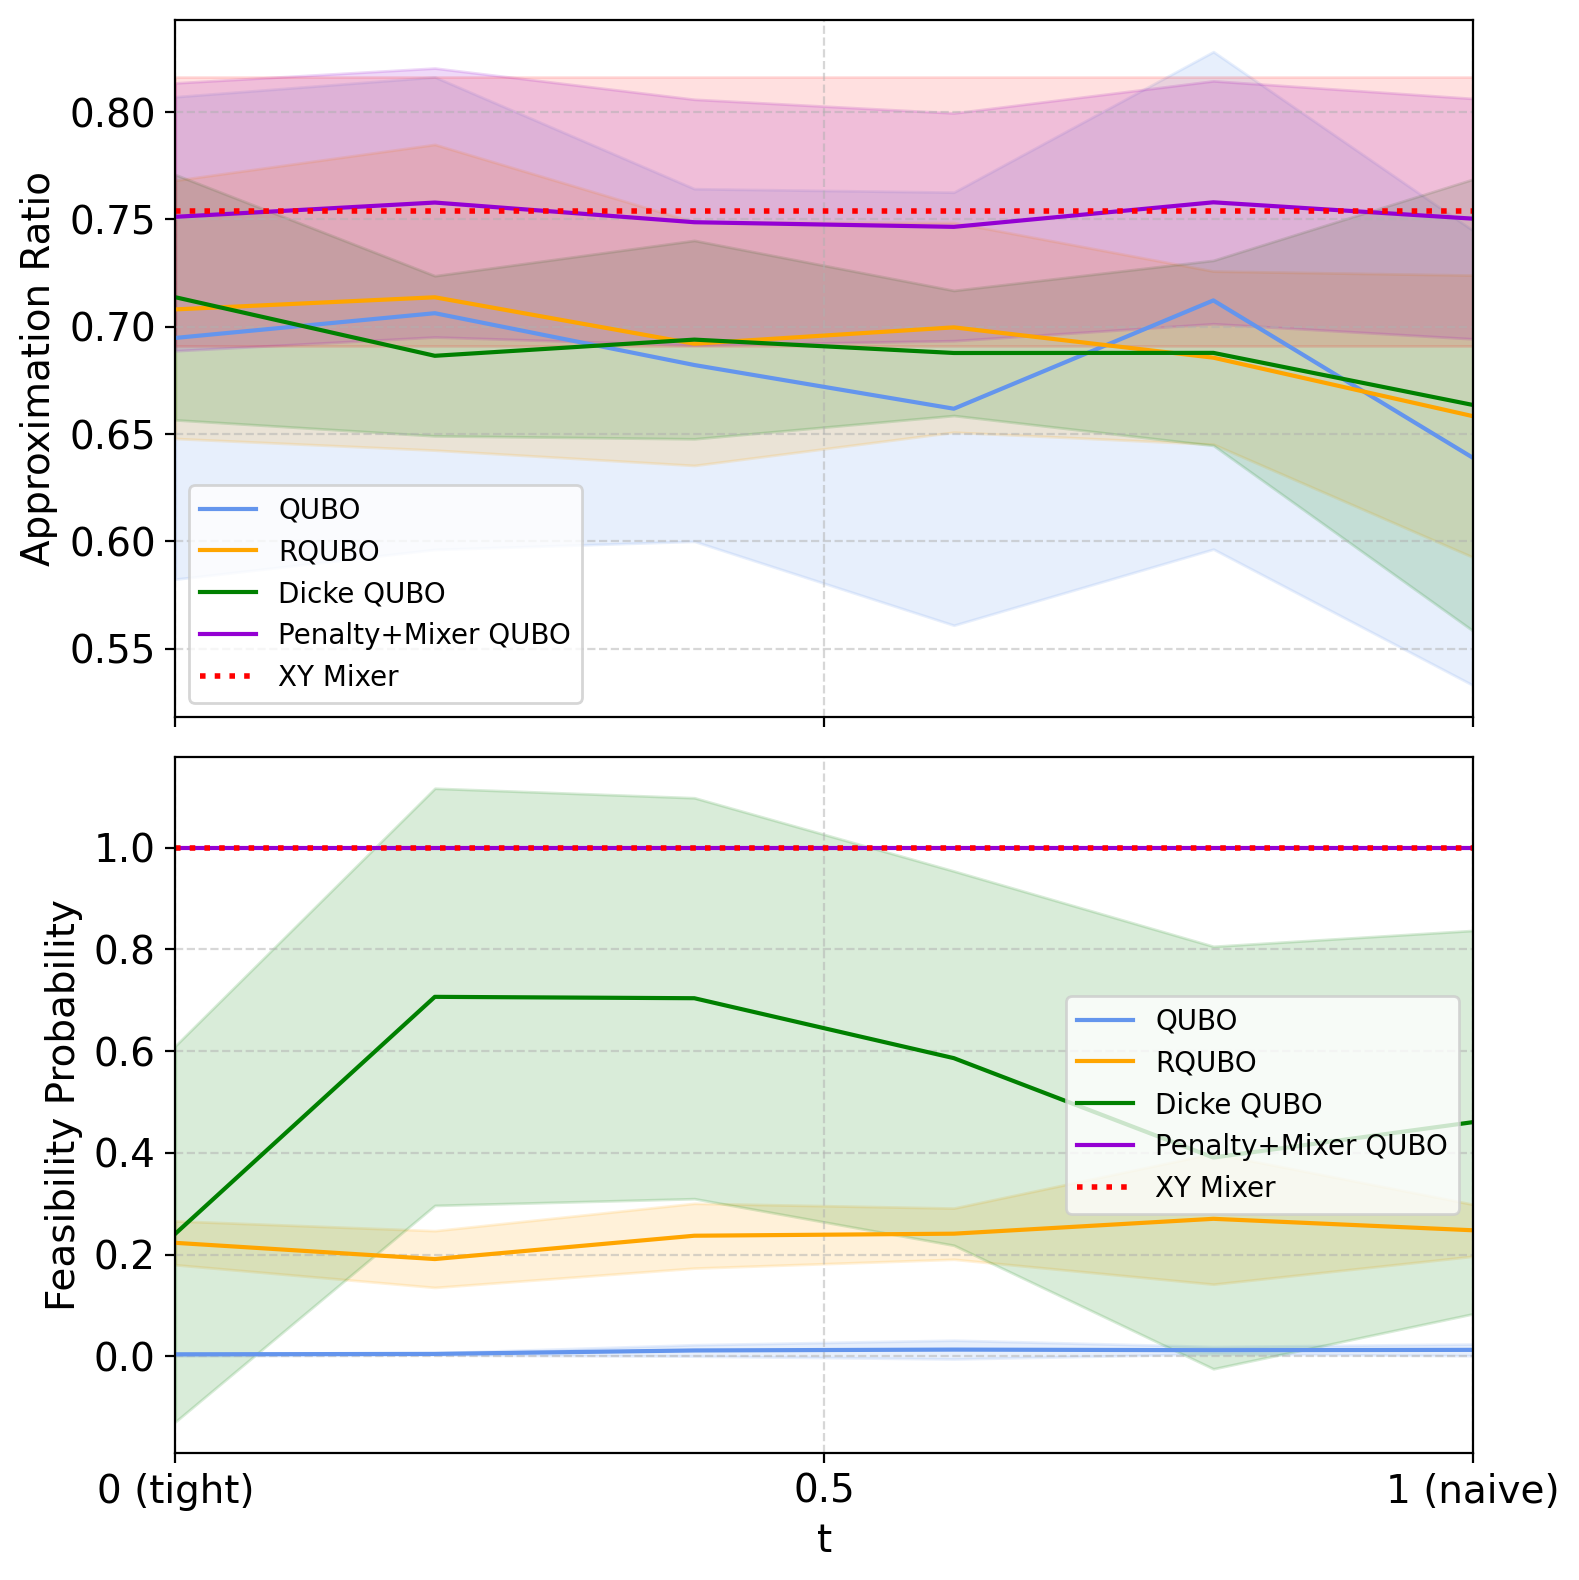

In [7]:
qubo_mean_over_graphs = average_non_zero(QUBO_EXP_VALS)
qubo_std_over_graphs = std_non_zero(QUBO_EXP_VALS)
rqubo_mean_over_graphs = average_non_zero(RQUBO_EXP_VALS)
rqubo_std_over_graphs = std_non_zero(RQUBO_EXP_VALS)

qubo_mean_feas_prob = np.mean(QUBO_FEASIBILITY, axis=0)
qubo_std_feas_prob = np.std(QUBO_FEASIBILITY, axis=0)
rqubo_mean_feas_prob = np.mean(RQUBO_FEASIBILITY, axis=0)
rqubo_std_feas_prob = np.std(RQUBO_FEASIBILITY, axis=0)

dicke_mean_over_graphs = None
penalty_mixer_mean_over_graphs = None
dicke_mean_feas_prob = None
penalty_mixer_mean_feas_prob = None

if DICKE_QUBO_EXP_VALS is not None:
    dicke_mean_over_graphs = average_non_zero(DICKE_QUBO_EXP_VALS)
    dicke_std_over_graphs = std_non_zero(DICKE_QUBO_EXP_VALS)
    dicke_mean_feas_prob = np.mean(DICKE_QUBO_FEASIBILITY, axis=0)
    dicke_std_feas_prob = np.std(DICKE_QUBO_FEASIBILITY, axis=0)

if PENALTY_MIXER_QUBO_EXP_VALS is not None:
    penalty_mixer_mean_over_graphs = average_non_zero(PENALTY_MIXER_QUBO_EXP_VALS)
    penalty_mixer_std_over_graphs = std_non_zero(PENALTY_MIXER_QUBO_EXP_VALS)
    penalty_mixer_mean_feas_prob = np.mean(PENALTY_MIXER_QUBO_FEASIBILITY, axis=0)
    penalty_mixer_std_feas_prob = np.std(PENALTY_MIXER_QUBO_FEASIBILITY, axis=0)

xy_mixer_mean = np.mean(XY_MIXER_EXP_VALS) if XY_MIXER_EXP_VALS is not None else None
xy_mixer_std = np.std(XY_MIXER_EXP_VALS) if XY_MIXER_EXP_VALS is not None and np.size(XY_MIXER_EXP_VALS) > 1 else None
xy_mixer_feas_mean = np.mean(XY_MIXER_FEASIBILITY) if XY_MIXER_FEASIBILITY is not None else None
xy_mixer_feas_std = np.std(XY_MIXER_FEASIBILITY) if XY_MIXER_FEASIBILITY is not None and np.size(XY_MIXER_FEASIBILITY) > 1 else None

# Plotting

# Custom colors:
qubo_color = "cornflowerblue"
rqubo_color = "orange"
dicke_qubo_color = "green"
penalty_mixer_color = "darkviolet"
xy_mixer_color = "red"

# Create a 2-row figure: top row for expected ratio, bottom row for feasibility probability.
# By specifying squeeze=False, axs is always a 2D array with shape (2, len(alpha_list))
fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

# -----------------------------
# Plot in the top row: Expected Approximation Ratio
# -----------------------------
ax_top = axs[0]
ax_top.plot(penalty_list, qubo_mean_over_graphs, label="QUBO", color=qubo_color, linestyle='-')
ax_top.fill_between(penalty_list,
                    np.array(qubo_mean_over_graphs) - np.array(qubo_std_over_graphs),
                    np.array(qubo_mean_over_graphs) + np.array(qubo_std_over_graphs),
                    color=qubo_color, alpha=0.15)

ax_top.plot(penalty_list, rqubo_mean_over_graphs, label="RQUBO", color=rqubo_color, linestyle='-')
ax_top.fill_between(penalty_list,
                    np.array(rqubo_mean_over_graphs) - np.array(rqubo_std_over_graphs),
                    np.array(rqubo_mean_over_graphs) + np.array(rqubo_std_over_graphs),
                    color=rqubo_color, alpha=0.15)

if dicke_mean_over_graphs is not None:
    ax_top.plot(penalty_list, dicke_mean_over_graphs, label="Dicke QUBO", color=dicke_qubo_color, linestyle='-')
    ax_top.fill_between(penalty_list,
                        np.array(dicke_mean_over_graphs) - np.array(dicke_std_over_graphs),
                        np.array(dicke_mean_over_graphs) + np.array(dicke_std_over_graphs),
                        color=dicke_qubo_color, alpha=0.15)

if penalty_mixer_mean_over_graphs is not None:
    ax_top.plot(penalty_list, penalty_mixer_mean_over_graphs, label="Penalty+Mixer QUBO", color=penalty_mixer_color, linestyle='-')
    ax_top.fill_between(penalty_list,
                        np.array(penalty_mixer_mean_over_graphs) - np.array(penalty_mixer_std_over_graphs),
                        np.array(penalty_mixer_mean_over_graphs) + np.array(penalty_mixer_std_over_graphs),
                        color=penalty_mixer_color, alpha=0.15)

if xy_mixer_mean is not None:
    ax_top.axhline(y=xy_mixer_mean, color=xy_mixer_color, linestyle=':', linewidth=2, label="XY Mixer")
    if xy_mixer_std is not None:
        ax_top.axhspan(xy_mixer_mean - xy_mixer_std, xy_mixer_mean + xy_mixer_std,
                       color=xy_mixer_color, alpha=0.12)

ax_top.grid(True, which='both', linestyle='--', alpha=0.5)
#ax_top.set_ylim(0, 1)
ax_top.set_ylabel('Approximation Ratio', fontsize=14)
ax_top.legend()
plt.grid

# -----------------------------
# Plot in the bottom row: Feasibility Probability
# -----------------------------
ax_bottom = axs[1]
ax_bottom.plot(penalty_list, qubo_mean_feas_prob, label="QUBO", color=qubo_color, linestyle='-')
ax_bottom.fill_between(penalty_list,
                    np.array(qubo_mean_feas_prob) - np.array(qubo_std_feas_prob),
                    np.array(qubo_mean_feas_prob) + np.array(qubo_std_feas_prob),
                    color=qubo_color, alpha=0.15)

ax_bottom.plot(penalty_list, rqubo_mean_feas_prob, label="RQUBO", color=rqubo_color, linestyle='-')
ax_bottom.fill_between(penalty_list,
                    np.array(rqubo_mean_feas_prob) - np.array(rqubo_std_feas_prob),
                    np.array(rqubo_mean_feas_prob) + np.array(rqubo_std_feas_prob),
                    color=rqubo_color, alpha=0.15)

if dicke_mean_feas_prob is not None:
    ax_bottom.plot(penalty_list, dicke_mean_feas_prob, label="Dicke QUBO", color=dicke_qubo_color, linestyle='-')
    ax_bottom.fill_between(penalty_list,
                        np.array(dicke_mean_feas_prob) - np.array(dicke_std_feas_prob),
                        np.array(dicke_mean_feas_prob) + np.array(dicke_std_feas_prob),
                        color=dicke_qubo_color, alpha=0.15)

if penalty_mixer_mean_feas_prob is not None:
    ax_bottom.plot(penalty_list, penalty_mixer_mean_feas_prob, label="Penalty+Mixer QUBO", color=penalty_mixer_color, linestyle='-')
    ax_bottom.fill_between(penalty_list,
                        np.array(penalty_mixer_mean_feas_prob) - np.array(penalty_mixer_std_feas_prob),
                        np.array(penalty_mixer_mean_feas_prob) + np.array(penalty_mixer_std_feas_prob),
                        color=penalty_mixer_color, alpha=0.15)

if xy_mixer_feas_mean is not None:
    ax_bottom.axhline(y=xy_mixer_feas_mean, color=xy_mixer_color, linestyle=':', linewidth=2, label="XY Mixer")
    if xy_mixer_feas_std is not None:
        ax_bottom.axhspan(xy_mixer_feas_mean - xy_mixer_feas_std, xy_mixer_feas_mean + xy_mixer_feas_std,
                          color=xy_mixer_color, alpha=0.12)

ax_bottom.grid(True, which='both', linestyle='--', alpha=0.5)
#ax_bottom.set_ylim(0, .5)
ax_bottom.set_xlabel('t', fontsize=14)
ax_bottom.set_xticks([0, 0.5, 1])
ax_bottom.set_xticklabels(["0 (tight)", "0.5", "1 (naive)"], fontsize=12)
ax_bottom.set_ylabel('Feasibility Probability', fontsize=14)
ax_bottom.legend()

for ax in axs:
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    plt.xlim(0, 1)

plt.tight_layout()

data_tag = os.path.splitext(os.path.basename(loaded_data_path))[0]
fig.savefig(os.path.join("Data", f"interpolated_penalties_{data_tag}.pdf"))

In [8]:
print("feasibility probability ratio:", rqubo_mean_feas_prob / qubo_mean_feas_prob)
print("average ratio:", np.mean(rqubo_mean_feas_prob / qubo_mean_feas_prob))

feasibility probability ratio: [53.12604043 37.77218935 20.01306914 17.84547135 21.90246864 19.0745867 ]
average ratio: 28.28897093334953


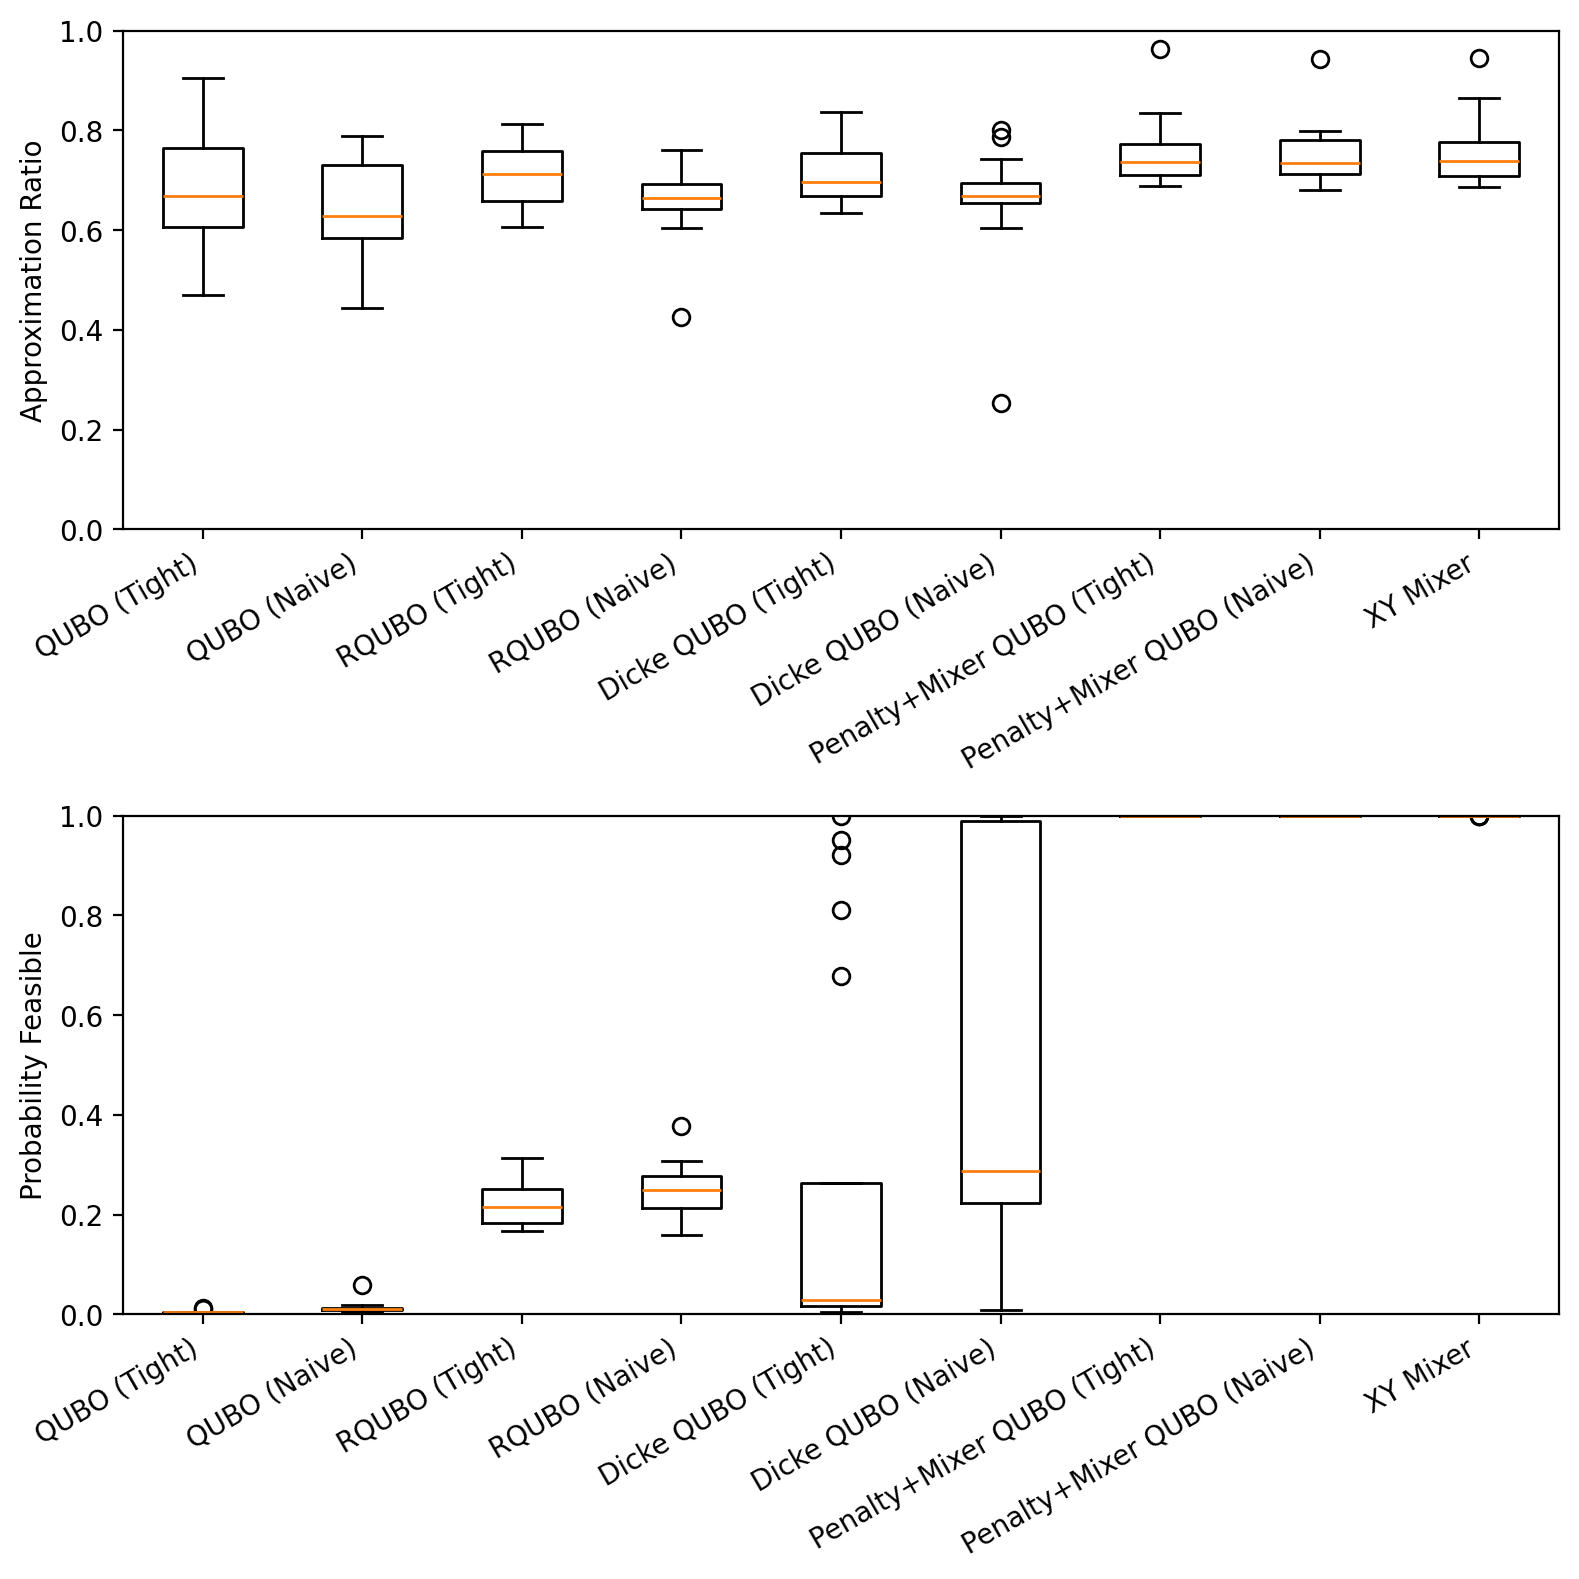

In [9]:
# Box Plot

def drop_zeros(values):
    return values[values != 0]

model_specs = [
    ("QUBO (Tight)", drop_zeros(QUBO_EXP_VALS[:, 0]), QUBO_FEASIBILITY[:, 0]),
    ("QUBO (Naive)", drop_zeros(QUBO_EXP_VALS[:, -1]), QUBO_FEASIBILITY[:, -1]),
    ("RQUBO (Tight)", drop_zeros(RQUBO_EXP_VALS[:, 0]), RQUBO_FEASIBILITY[:, 0]),
    ("RQUBO (Naive)", drop_zeros(RQUBO_EXP_VALS[:, -1]), RQUBO_FEASIBILITY[:, -1]),
]

if DICKE_QUBO_EXP_VALS is not None:
    model_specs.append(("Dicke QUBO (Tight)", drop_zeros(DICKE_QUBO_EXP_VALS[:, 0]), DICKE_QUBO_FEASIBILITY[:, 0]))
    model_specs.append(("Dicke QUBO (Naive)", drop_zeros(DICKE_QUBO_EXP_VALS[:, -1]), DICKE_QUBO_FEASIBILITY[:, -1]))

if PENALTY_MIXER_QUBO_EXP_VALS is not None:
    model_specs.append(("Penalty+Mixer QUBO (Tight)", drop_zeros(PENALTY_MIXER_QUBO_EXP_VALS[:, 0]), PENALTY_MIXER_QUBO_FEASIBILITY[:, 0]))
    model_specs.append(("Penalty+Mixer QUBO (Naive)", drop_zeros(PENALTY_MIXER_QUBO_EXP_VALS[:, -1]), PENALTY_MIXER_QUBO_FEASIBILITY[:, -1]))

if XY_MIXER_EXP_VALS is not None:
    model_specs.append(("XY Mixer", drop_zeros(XY_MIXER_EXP_VALS), XY_MIXER_FEASIBILITY))

model_labels = [label for label, _, _ in model_specs]
model_means = {label: values for label, values, _ in model_specs}
model_feasibility_probs = {label: feas for label, _, feas in model_specs}

fig, axs = plt.subplots(2, 1, figsize=(8, 8))

# First subplot: Approximation Ratio
data_for_boxplot = [model_means[label] for label in model_labels]
axs[0].boxplot(data_for_boxplot, tick_labels=model_labels)
axs[0].set_ylabel("Approximation Ratio")
axs[0].set_xticklabels(model_labels, rotation=30, ha='right')
axs[0].set_ylim(0, 1)

# Second subplot: Probability Feasible
data_for_boxplot = [model_feasibility_probs[label] for label in model_labels]
axs[1].boxplot(data_for_boxplot, tick_labels=model_labels)
axs[1].set_ylabel("Probability Feasible")
axs[1].set_xticklabels(model_labels, rotation=30, ha='right')
axs[1].set_ylim(0, 1)

plt.tight_layout()

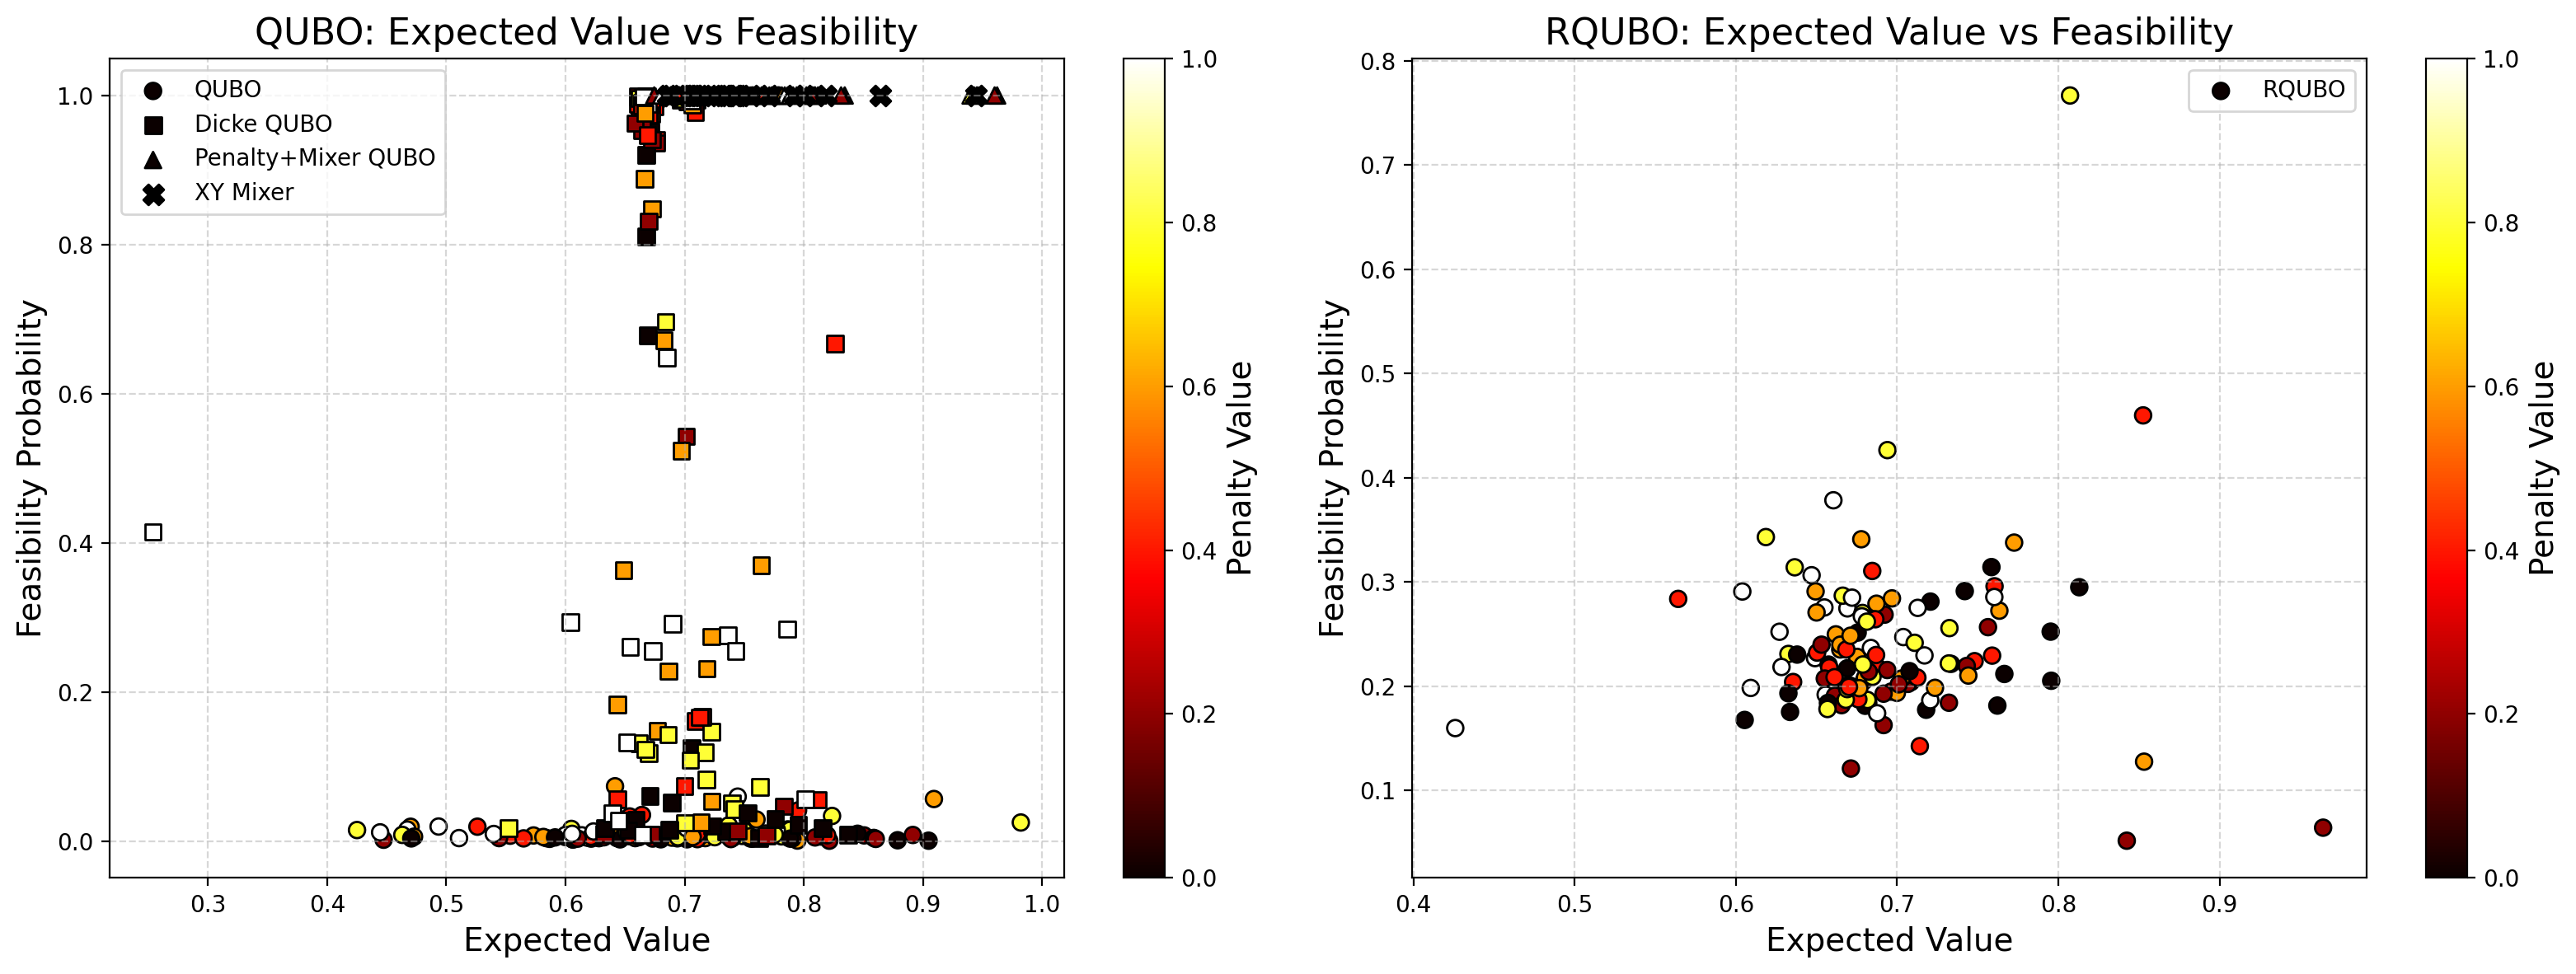

In [10]:
# Scatter of ALL data points

# Create color arrays for scatter plots.
# For each row (graph) we assign the penalty_list values.
colors = np.tile(penalty_list, (QUBO_EXP_VALS.shape[0], 1))  # shape (num_graphs, num_penalties)

# Flatten the matrices for plotting
qubo_exp_flat = QUBO_EXP_VALS.flatten()
qubo_feas_flat = QUBO_FEASIBILITY.flatten()
rqubo_exp_flat = RQUBO_EXP_VALS.flatten()
rqubo_feas_flat = RQUBO_FEASIBILITY.flatten()
colors_flat = colors.flatten()

dicke_exp_flat = DICKE_QUBO_EXP_VALS.flatten() if DICKE_QUBO_EXP_VALS is not None else None
dicke_feas_flat = DICKE_QUBO_FEASIBILITY.flatten() if DICKE_QUBO_FEASIBILITY is not None else None
pm_exp_flat = PENALTY_MIXER_QUBO_EXP_VALS.flatten() if PENALTY_MIXER_QUBO_EXP_VALS is not None else None
pm_feas_flat = PENALTY_MIXER_QUBO_FEASIBILITY.flatten() if PENALTY_MIXER_QUBO_FEASIBILITY is not None else None

# Create figure with two subplots.
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot for QUBO results
sc0 = axs[0].scatter(qubo_exp_flat, qubo_feas_flat, c=colors_flat, cmap='hot', s=50, edgecolor='k', label="QUBO")

if dicke_exp_flat is not None:
    axs[0].scatter(dicke_exp_flat, dicke_feas_flat, c=colors_flat, cmap='hot', s=50, edgecolor='k', marker='s', label="Dicke QUBO")
if pm_exp_flat is not None:
    axs[0].scatter(pm_exp_flat, pm_feas_flat, c=colors_flat, cmap='hot', s=50, edgecolor='k', marker='^', label="Penalty+Mixer QUBO")
if XY_MIXER_EXP_VALS is not None:
    axs[0].scatter(XY_MIXER_EXP_VALS, XY_MIXER_FEASIBILITY, color='black', s=80, marker='X', label="XY Mixer")

axs[0].set_xlabel('Expected Value', fontsize=14)
axs[0].set_ylabel('Feasibility Probability', fontsize=14)
axs[0].set_title('QUBO: Expected Value vs Feasibility', fontsize=16)
axs[0].grid(True, which='both', linestyle='--', alpha=0.5)
axs[0].legend(fontsize=10)
cbar0 = plt.colorbar(sc0, ax=axs[0])
cbar0.set_label('Penalty Value', fontsize=14)

# Scatter plot for RQUBO results
sc1 = axs[1].scatter(rqubo_exp_flat, rqubo_feas_flat, c=colors_flat, cmap='hot', s=50, edgecolor='k', label="RQUBO")
axs[1].set_xlabel('Expected Value', fontsize=14)
axs[1].set_ylabel('Feasibility Probability', fontsize=14)
axs[1].set_title('RQUBO: Expected Value vs Feasibility', fontsize=16)
axs[1].grid(True, which='both', linestyle='--', alpha=0.5)
axs[1].legend(fontsize=10)
cbar1 = plt.colorbar(sc1, ax=axs[1])
cbar1.set_label('Penalty Value', fontsize=14)

plt.tight_layout()
plt.show()